# Phase 3: General-Purpose Siamese Network with Triplet Hard-Negative Mining (V2.2)

Multi-signer training pipeline using **Triplet Margin Loss with Online Hard-Negative Mining** on the `extract/` dataset (~687 signers, ~14,626 images).

### Key Architecture & Metric Improvements:
- **ResNet-18 Backbone + Projection Head**: Produces 128-dimensional $L_2$-normalized feature vectors.
- **Triplet Loss with Cosine Distance**:
  $$\mathcal{L} = \max\Big(d(Anchor, Positive) - d(Anchor, Negative) + \text{margin},\ 0\Big)$$
  where $d(x, y) = 1.0 - \cos(x, y)$ and $\text{margin} = 0.4$.
- **Hard-Negative Mining**: Explicitly samples skilled forgeries of the *same signer identity* (~70%) as hard negatives, forcing the network to learn subtle pen stroke dynamics, curvature, and pressure transitions.
- **Signer-Level Disjoint Split (80/20)**: Zero signer identity overlap between train and validation sets (true open-set biometric evaluation).
- **Two-Phase Training**: Phase 1 warms up the projection head with frozen backbone; Phase 2 fine-tunes all layers with differential learning rates and cosine annealing.
- **Inference Compatibility**: 100% compatible with existing FastAPI engine (`POST /verify`) and 3-tier verdict framework.

In [1]:
import os
import glob
import re
import json
import random
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from sklearn.metrics import roc_auc_score, roc_curve

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print('matplotlib not available, skipping visualizations')

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

# ---- GPU Detection ----
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

if DEVICE.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB VRAM)')
    torch.backends.cudnn.benchmark = True
else:
    print('='*60)
    print('WARNING: CUDA NOT DETECTED! Training will be VERY SLOW.')
    print('Make sure the kernel uses a CUDA-enabled PyTorch.')
    print('='*60)

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (6.0 GB VRAM)


### 1. Model Architecture: ResNet18 + Projection Head

```
Input (224x224 RGB)
       │
       ▼
ResNet-18 Backbone (conv1 through layer4)
       │
       ▼
AdaptiveAvgPool2d ──> 512-dim feature vector
       │
       ▼
Projection Head:
  Linear(512, 256) ──> BatchNorm1d ──> ReLU ──> Dropout(0.3) ──> Linear(256, 128)
       │
       ▼
L2-Normalization (unit hypersphere) ──> 128-dim Embedding
```

The network supports single forward pass (`forward_once` for inference) and triplet forward passes (`forward(anchor, positive, negative)` for training).

In [2]:
class SiameseNetwork(nn.Module):
    '''Siamese Network: ResNet18 backbone + Projection Head.
    Produces L2-normalized 128-dimensional embeddings for metric learning.
    Supports single embedding extraction, pairwise evaluation, and triplet training.
    '''
    def __init__(self, embedding_dim=128):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Retain all convolutional layers except final classification fc
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.projection = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, embedding_dim),
        )

    def forward_once(self, x):
        '''Extract a single L2-normalized embedding vector.'''
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.projection(x)
        return F.normalize(x, p=2, dim=1)

    def forward(self, x1, x2=None, x3=None):
        '''Flexible forward pass:
        - 1 tensor: returns single embedding e1
        - 2 tensors: returns pair (e1, e2) for evaluation
        - 3 tensors: returns triplet (anchor, positive, negative) for training
        '''
        e1 = self.forward_once(x1)
        if x2 is None:
            return e1
        e2 = self.forward_once(x2)
        if x3 is None:
            return e1, e2
        e3 = self.forward_once(x3)
        return e1, e2, e3

# Initialize model
model = SiameseNetwork(embedding_dim=128).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model initialized on {DEVICE}')
print(f'Total parameters: {total_params:,} | Trainable: {trainable_params:,}')

Model initialized on cuda
Total parameters: 11,341,248 | Trainable: 11,341,248


### 2. Robust Preprocessing Pipeline

- **Otsu binarization** for stroke isolation
- **Morphological closing** to connect nearby strokes
- **Merged bounding box** from ALL contours (captures disconnected strokes)
- **Aspect-ratio preserving resize** (pad to square, then resize to 224x224)

Test image path: ../extract/001/original_1_1.jpg
Preprocessed: (224, 224, 3), range [31, 255]


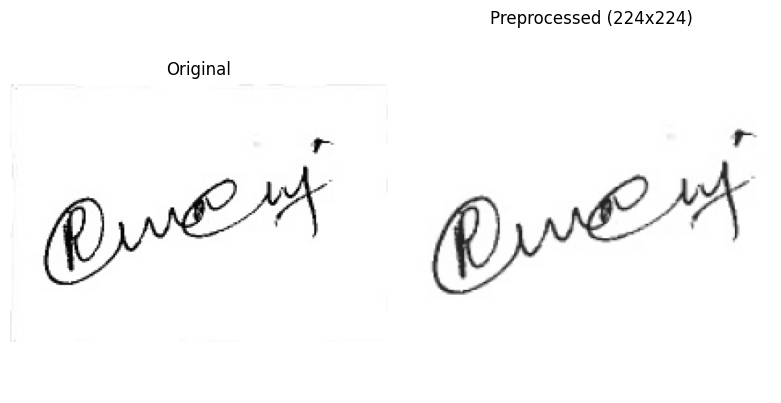

In [3]:
def preprocess_signature(image_path):
    '''Preprocess a signature image: isolate strokes, crop, pad, resize.
    Returns a 224x224x3 numpy array (uint8).
    '''
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'Could not read image: {image_path}')

    # 1. Blur to smooth sensor noise
    blurred = cv2.GaussianBlur(img, (5, 5), 0)

    # 2. Otsu thresholding (strokes = white, background = black)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. Morphological closing to bridge small stroke gaps
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # 4. Find bounding box of ALL strokes combined
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        pts = np.vstack(contours)
        x, y, w, h = cv2.boundingRect(pts)
        pad = 10
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(img.shape[1], x + w + pad), min(img.shape[0], y + h + pad)
        cropped = img[y1:y2, x1:x2]
    else:
        cropped = img

    # 5. Aspect-ratio preserving pad to square (white background)
    ch, cw = cropped.shape
    side = max(ch, cw)
    square = np.full((side, side), 255, dtype=np.uint8)
    oy = (side - ch) // 2
    ox = (side - cw) // 2
    square[oy:oy + ch, ox:ox + cw] = cropped

    # 6. Resize to 224x224 and convert to 3-channel
    resized = cv2.resize(square, (224, 224), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)

# Quick test using specimen from extract/001/
test_path = sorted(glob.glob('../extract/001/original_1_1.jpg'))[0]
test_img = preprocess_signature(test_path)
print(f'Test image path: {test_path}')
print(f'Preprocessed: {test_img.shape}, range [{test_img.min()}, {test_img.max()}]')

if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(cv2.imread(test_path, cv2.IMREAD_GRAYSCALE), cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(test_img)
    axes[1].set_title('Preprocessed (224x224)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

### 3. Multi-Identity Triplet Generation with Online Hard-Negative Mining

To train the network for open-set forensic verification, we construct informative triplets per signer:
- **Anchor**: Genuine signature of signer $S$.
- **Positive**: Different genuine signature of the same signer $S$.
- **Hard Negative (~70%)**: Skilled forgery targeting signer $S$ (same visual intent, forged stroke anatomy).
- **Random Negative (~30%)**: Genuine signature from a completely different signer $S' \neq S$.

This formulation penalizes false acceptances on skilled forgeries, resolving the primary bottleneck of EER in standard contrastive training.

In [4]:
class TripletSignatureDataset(Dataset):
    '''Generates (anchor, positive, negative) triplets for multi-identity metric learning.
    
    Hard negatives are sampled from skilled forgeries of the same signer,
    while random negatives are sampled from other signers.
    '''
    def __init__(self, genuine_by_signer, forgery_by_signer, signer_ids,
                 triplets_per_signer=30, hard_neg_ratio=0.7, transform=None):
        self.transform = transform
        self.triplets = []

        for sid in signer_ids:
            gen = genuine_by_signer.get(sid, [])
            if len(gen) < 2:
                continue
            forg = forgery_by_signer.get(sid, [])
            others = [s for s in signer_ids if s != sid and len(genuine_by_signer.get(s, [])) > 0]

            n_hard = int(triplets_per_signer * hard_neg_ratio) if forg else 0
            n_rand = triplets_per_signer - n_hard

            # 1. Hard Negative Triplets: (Genuine_A, Genuine_B, SkilledForgery)
            if forg and n_hard > 0:
                for _ in range(n_hard):
                    i, j = random.sample(range(len(gen)), 2)
                    neg_path = random.choice(forg)
                    self.triplets.append((gen[i], gen[j], neg_path, 'hard'))

            # 2. Random Negative Triplets: (Genuine_A, Genuine_B, DifferentSignerGenuine)
            if others and n_rand > 0:
                for _ in range(n_rand):
                    i, j = random.sample(range(len(gen)), 2)
                    other_sid = random.choice(others)
                    neg_path = random.choice(genuine_by_signer[other_sid])
                    self.triplets.append((gen[i], gen[j], neg_path, 'random'))

        n_hard_total = sum(1 for t in self.triplets if t[3] == 'hard')
        n_rand_total = sum(1 for t in self.triplets if t[3] == 'random')
        print(f'Dataset: {len(self)} triplets | Hard Negatives (Skilled): {n_hard_total} | Random Negatives: {n_rand_total}')

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, index):
        a_path, p_path, n_path, _ = self.triplets[index]

        img_a = preprocess_signature(a_path)
        img_p = preprocess_signature(p_path)
        img_n = preprocess_signature(n_path)

        if self.transform:
            img_a = self.transform(img_a)
            img_p = self.transform(img_p)
            img_n = self.transform(img_n)

        return img_a, img_p, img_n

print('TripletSignatureDataset ready.')

TripletSignatureDataset ready.


### 4. Data Loading & Configuration

- 80/20 signer-level split (no data leakage)
- 80 pairs per type for training, 60 for validation
- Batch size 16 (optimized for RTX 4050 6GB VRAM)
- Augmentation: rotation, perspective, blur, jitter, affine

In [7]:
# ---- Parse dataset directly from extract/ ----
genuine_by_signer = defaultdict(list)
forgery_by_signer = defaultdict(list)

for path in sorted(glob.glob('../extract/*/original_*.jpg')):
    if '_forg' in path:
        continue
    match = re.search(r'original_(\d+)_(\d+)\.jpg', os.path.basename(path))
    if match:
        genuine_by_signer[int(match.group(1))].append(path)

for path in sorted(glob.glob('../extract/*_forg/forgeries_*.jpg')):
    match = re.search(r'forgeries_(\d+)_(\d+)\.jpg', os.path.basename(path))
    if match:
        forgery_by_signer[int(match.group(1))].append(path)

all_signers = sorted(list(set(genuine_by_signer.keys()) & set(forgery_by_signer.keys())))
print(f'Signers: {len(all_signers)}')
print(f'Genuine: {sum(len(v) for v in genuine_by_signer.values())} images')
print(f'Forgery: {sum(len(v) for v in forgery_by_signer.values())} images')

# ---- Signer-level split (80/20) ----
random.seed(42)
shuffled_signers = all_signers.copy()
random.shuffle(shuffled_signers)
split_idx = int(len(shuffled_signers) * 0.8)
train_signers = shuffled_signers[:split_idx]
val_signers = shuffled_signers[split_idx:]
print(f'Train: {len(train_signers)} signers | Val: {len(val_signers)} signers')

# ---- Transforms (aggressive data augmentation) ----
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=12),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.4),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ---- Dataset & DataLoader ----
train_triplets_per_signer = max(10, min(60, 16000 // max(1, len(train_signers))))
val_triplets_per_signer = max(10, min(40, 4000 // max(1, len(val_signers))))

train_dataset = TripletSignatureDataset(
    genuine_by_signer, forgery_by_signer, train_signers,
    triplets_per_signer=train_triplets_per_signer, hard_neg_ratio=0.7, transform=train_transform
)
val_dataset = TripletSignatureDataset(
    genuine_by_signer, forgery_by_signer, val_signers,
    triplets_per_signer=val_triplets_per_signer, hard_neg_ratio=0.7, transform=val_transform
)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_dataset)} triplets, {len(train_loader)} batches')
print(f'Val:   {len(val_dataset)} triplets, {len(val_loader)} batches')

Signers: 687
Genuine: 7313 images
Forgery: 7313 images
Train: 549 signers | Val: 138 signers
Dataset: 15921 triplets | Hard Negatives (Skilled): 10980 | Random Negatives: 4941
Dataset: 3864 triplets | Hard Negatives (Skilled): 2622 | Random Negatives: 1242
Train: 15921 triplets, 995 batches
Val:   3864 triplets, 242 batches


### 5. Two-Phase Training with Triplet Margin Distance Loss

We employ `nn.TripletMarginWithDistanceLoss` using **Cosine Distance**:
$$d(x, y) = 1.0 - \text{cosine\_similarity}(x, y)$$
with a target separation margin of $\alpha = 0.40$.

**Phase 1 (10 epochs):** Backbone FROZEN. Only the projection head learns signature-specific embeddings.
**Phase 2 (40 epochs):** Backbone UNFROZEN with differential learning rates:
- Backbone: `5e-5` (gentle fine-tuning of convolutional filters)
- Projection head: `3e-4` (continues metric learning)
- Scheduler: `CosineAnnealingLR` with early stopping patience.

**Mixed Precision (AMP)** is enabled on CUDA for accelerated execution.

In [9]:
os.makedirs('../models', exist_ok=True)

use_amp = (DEVICE.type == 'cuda')
scaler = torch.amp.GradScaler('cuda', enabled=use_amp) if use_amp else torch.amp.GradScaler('cpu')

# Triplet Margin Distance Loss with Cosine Distance
MARGIN = 0.4
criterion = nn.TripletMarginWithDistanceLoss(
    distance_function=lambda x, y: 1.0 - F.cosine_similarity(x, y),
    margin=MARGIN
)

def run_epoch(loader, training=True):
    '''Run one epoch of triplet training or validation.'''
    model.train() if training else model.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    device_type = 'cuda' if DEVICE.type == 'cuda' else 'cpu'
    with ctx:
        for anchor, positive, negative in loader:
            anchor = anchor.to(DEVICE, non_blocking=True)
            positive = positive.to(DEVICE, non_blocking=True)
            negative = negative.to(DEVICE, non_blocking=True)

            if training:
                optimizer.zero_grad()

            with torch.amp.autocast(device_type, enabled=use_amp):
                emb_a, emb_p, emb_n = model(anchor, positive, negative)
                loss = criterion(emb_a, emb_p, emb_n)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item()
    return total_loss / len(loader)

# ============================================================
# RESUME CONFIGURATION
# ============================================================
RESUME_TRAINING = True  # True: Lanjut dari model terbaik yang sudah tersimpan
SAVED_MODEL_PATH = '../models/forensic_signature_v2.pt'

# Riwayat training sebelumnya (Phase 1 [1-10] & Phase 2 [1-23])
prev_p1_train = [0.2840, 0.2716, 0.2626, 0.2612, 0.2572, 0.2527, 0.2500, 0.2493, 0.2495, 0.2515]
prev_p1_val   = [0.2254, 0.2275, 0.2266, 0.2231, 0.2266, 0.2235, 0.2229, 0.2210, 0.2156, 0.2185]
prev_p2_train = [0.1701, 0.1149, 0.0905, 0.0716, 0.0599, 0.0492, 0.0393, 0.0341, 0.0298, 0.0254,
                 0.0234, 0.0193, 0.0174, 0.0171, 0.0137, 0.0132, 0.0128, 0.0118, 0.0099, 0.0083,
                 0.0085, 0.0074, 0.0066]
prev_p2_val   = [0.1400, 0.1298, 0.1244, 0.1276, 0.1275, 0.1295, 0.1264, 0.1226, 0.1248, 0.1203,
                 0.1264, 0.1158, 0.1139, 0.1210, 0.1112, 0.1141, 0.1127, 0.1087, 0.1194, 0.1119,
                 0.1123, 0.1157, 0.1177]

if RESUME_TRAINING and os.path.exists(SAVED_MODEL_PATH):
    print('=' * 60)
    print('RESUME MODE: Memuat bobot terbaik dari forensic_signature_v2.pt')
    print('=' * 60)
    model.load_state_dict(torch.load(SAVED_MODEL_PATH, map_location=DEVICE, weights_only=True))
    best_val_loss = 0.1087
    history = {
        'train_loss': list(prev_p1_train + prev_p2_train),
        'val_loss': list(prev_p1_val + prev_p2_val),
        'phase': [1] * len(prev_p1_train) + [2] * len(prev_p2_train),
    }
    print(f'Model berhasil dimuat! Best val loss sebelumnya: {best_val_loss:.4f}')
    print('Phase 1 (10 epochs) SUDAH SELESAI -> Melewati Phase 1, langsung lanjut Phase 2.\n')
else:
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'phase': []}

    # ============================================================
    # PHASE 1: Train Projection Head Only (Backbone Frozen)
    # ============================================================
    print('=' * 60)
    print('PHASE 1: Projection Head Training (backbone frozen)')
    print('=' * 60)

    for param in model.features.parameters():
        param.requires_grad = False

    optimizer = optim.Adam(model.projection.parameters(), lr=0.001, weight_decay=1e-4)
    PHASE1_EPOCHS = 10

    for epoch in range(PHASE1_EPOCHS):
        t_loss = run_epoch(train_loader, training=True)
        v_loss = run_epoch(val_loader, training=False)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['phase'].append(1)

        marker = ''
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), SAVED_MODEL_PATH)
            marker = ' << best'

        print(f'P1 [{epoch+1:02d}/{PHASE1_EPOCHS}] '
              f'Train: {t_loss:.4f} | Val: {v_loss:.4f}{marker}')

    print(f'Phase 1 done. Best val loss: {best_val_loss:.4f}\n')

# ============================================================
# PHASE 2: Full Fine-tuning (All Layers Unfrozen)
# ============================================================
print('=' * 60)
print('PHASE 2: Full Fine-tuning (differential LR)')
print('=' * 60)

for param in model.features.parameters():
    param.requires_grad = True

optimizer = optim.Adam([
    {'params': model.features.parameters(), 'lr': 5e-5},
    {'params': model.projection.parameters(), 'lr': 3e-4},
], weight_decay=1e-4)

PHASE2_EPOCHS = 40
patience = 12
start_epoch_p2 = len(prev_p2_train) if (RESUME_TRAINING and os.path.exists(SAVED_MODEL_PATH)) else 0
patience_counter = 5 if (RESUME_TRAINING and os.path.exists(SAVED_MODEL_PATH)) else 0

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=PHASE2_EPOCHS, eta_min=1e-6
)

# Sinkronkan learning rate scheduler ke posisi epoch terakhir
for _ in range(start_epoch_p2):
    scheduler.step()

if start_epoch_p2 > 0:
    cur_lr_f = optimizer.param_groups[0]['lr']
    cur_lr_p = optimizer.param_groups[1]['lr']
    print(f'Melanjutkan Phase 2 dari Epoch [{start_epoch_p2 + 1:02d}/{PHASE2_EPOCHS}]')
    print(f'Current LR: Backbone={cur_lr_f:.6f}, Head={cur_lr_p:.6f} | Patience: {patience_counter}/{patience}\n')

for epoch in range(start_epoch_p2, PHASE2_EPOCHS):
    t_loss = run_epoch(train_loader, training=True)
    v_loss = run_epoch(val_loader, training=False)
    scheduler.step()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['phase'].append(2)

    marker = ''
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_counter = 0
        torch.save(model.state_dict(), SAVED_MODEL_PATH)
        marker = ' << best'
    else:
        patience_counter += 1

    lr_f = optimizer.param_groups[0]['lr']
    lr_p = optimizer.param_groups[1]['lr']
    print(f'P2 [{epoch+1:02d}/{PHASE2_EPOCHS}] '
          f'Train: {t_loss:.4f} | Val: {v_loss:.4f} | '
          f'LR: {lr_f:.6f}/{lr_p:.6f}{marker}')

    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch+1} (patience reached)')
        break

print(f'\nTraining complete! Best val loss: {best_val_loss:.4f}')

RESUME MODE: Memuat bobot terbaik dari forensic_signature_v2.pt
Model berhasil dimuat! Best val loss sebelumnya: 0.1087
Phase 1 (10 epochs) SUDAH SELESAI -> Melewati Phase 1, langsung lanjut Phase 2.

PHASE 2: Full Fine-tuning (differential LR)
Melanjutkan Phase 2 dari Epoch [24/40]
Current LR: Backbone=0.000020, Head=0.000116 | Patience: 5/12



c:\Users\subki\anaconda3\envs\forensicsignature\lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


P2 [24/40] Train: 0.0086 | Val: 0.1171 | LR: 0.000018/0.000104
P2 [25/40] Train: 0.0074 | Val: 0.1156 | LR: 0.000016/0.000093
P2 [26/40] Train: 0.0058 | Val: 0.1138 | LR: 0.000014/0.000083
P2 [27/40] Train: 0.0051 | Val: 0.1113 | LR: 0.000013/0.000072
P2 [28/40] Train: 0.0044 | Val: 0.1088 | LR: 0.000011/0.000063
P2 [29/40] Train: 0.0041 | Val: 0.1130 | LR: 0.000010/0.000053
P2 [30/40] Train: 0.0045 | Val: 0.1124 | LR: 0.000008/0.000045

Early stopping at epoch 30 (patience reached)

Training complete! Best val loss: 0.1087


### 6. Forensic Performance Audit & Threshold Calibration

Evaluate on validation signers (completely unseen during training) using standard biometric verification protocol:
- Compare Genuine vs Genuine ($+1$) and Genuine vs Skilled Forgery ($-1$)
- Calculate **ROC-AUC** (Target: $> 0.92$)
- Calculate **Equal Error Rate (EER)** (Target: $< 12\%$)
- Compute optimal threshold via **Youden's J statistic**

Genuine pairs: 3864 | Forgery pairs: 3864

Score Distribution:
  Genuine  - Mean: 0.7195, Min: -0.4975, Max: 0.9933
  Forgery  - Mean: 0.1841, Min: -0.8420, Max: 0.9563

ROC-AUC: 0.8933
EER: 0.1863 at threshold: 0.5575
Optimal Threshold (Youden J): 0.5770
  TPR: 0.8023, FPR: 0.1680

Score separation gap: 0.5354

ROC-AUC: 0.8933  NEEDS IMPROVEMENT
EER:     0.1863  NEEDS IMPROVEMENT
Gap:     0.5354  PASS


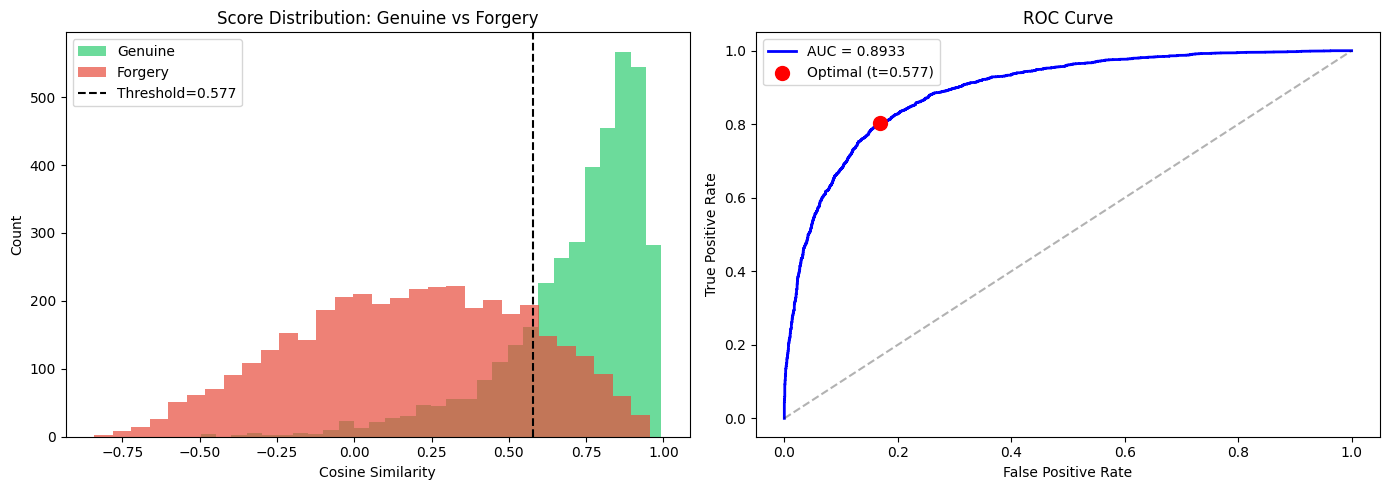

Plots saved to models/evaluation_plots.png


In [10]:
# Load best model
model.load_state_dict(torch.load(
    '../models/forensic_signature_v2.pt', map_location=DEVICE, weights_only=True
))
model.eval()

genuine_scores = []
forgery_scores = []

device_type = 'cuda' if DEVICE.type == 'cuda' else 'cpu'
with torch.no_grad():
    for anchor, positive, negative in val_loader:
        anchor = anchor.to(DEVICE, non_blocking=True)
        positive = positive.to(DEVICE, non_blocking=True)
        negative = negative.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type, enabled=use_amp):
            emb_a, emb_p, emb_n = model(anchor, positive, negative)
        sim_pos = F.cosine_similarity(emb_a, emb_p).cpu().numpy()
        sim_neg = F.cosine_similarity(emb_a, emb_n).cpu().numpy()
        genuine_scores.extend(float(s) for s in sim_pos)
        forgery_scores.extend(float(s) for s in sim_neg)

print(f'Genuine pairs: {len(genuine_scores)} | Forgery pairs: {len(forgery_scores)}')
print(f'\nScore Distribution:')
print(f'  Genuine  - Mean: {np.mean(genuine_scores):.4f}, '
      f'Min: {np.min(genuine_scores):.4f}, Max: {np.max(genuine_scores):.4f}')
print(f'  Forgery  - Mean: {np.mean(forgery_scores):.4f}, '
      f'Min: {np.min(forgery_scores):.4f}, Max: {np.max(forgery_scores):.4f}')

# ---- ROC-AUC ----
all_scores = genuine_scores + forgery_scores
all_labels = [1] * len(genuine_scores) + [0] * len(forgery_scores)
auc = roc_auc_score(all_labels, all_scores)
print(f'\nROC-AUC: {auc:.4f}')

# ---- EER ----
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
eer_threshold = float(thresholds[eer_idx])
print(f'EER: {eer:.4f} at threshold: {eer_threshold:.4f}')

# ---- Optimal threshold (Youden J) ----
j_scores = tpr - fpr
opt_idx = np.argmax(j_scores)
optimal_threshold = float(thresholds[opt_idx])
print(f'Optimal Threshold (Youden J): {optimal_threshold:.4f}')
print(f'  TPR: {tpr[opt_idx]:.4f}, FPR: {fpr[opt_idx]:.4f}')

gap = np.mean(genuine_scores) - np.mean(forgery_scores)
print(f'\nScore separation gap: {gap:.4f}')

# ---- Status ----
print(f'\n{"=" * 40}')
print(f'ROC-AUC: {auc:.4f}  {"PASS" if auc > 0.90 else "NEEDS IMPROVEMENT"}')
print(f'EER:     {eer:.4f}  {"PASS" if eer < 0.15 else "NEEDS IMPROVEMENT"}')
print(f'Gap:     {gap:.4f}  {"PASS" if gap > 0.40 else "NEEDS IMPROVEMENT"}')
print(f'{"=" * 40}')

# ---- Visualize ----
if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(genuine_scores, bins=30, alpha=0.7, label='Genuine', color='#2ecc71')
    axes[0].hist(forgery_scores, bins=30, alpha=0.7, label='Forgery', color='#e74c3c')
    axes[0].axvline(x=optimal_threshold, color='black', linestyle='--',
                    label=f'Threshold={optimal_threshold:.3f}')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Score Distribution: Genuine vs Forgery')
    axes[0].legend()

    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[1].scatter(fpr[opt_idx], tpr[opt_idx], c='red', s=100, zorder=5,
                    label=f'Optimal (t={optimal_threshold:.3f})')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('../models/evaluation_plots.png', dpi=150)
    plt.show()
    print('Plots saved to models/evaluation_plots.png')

### 7. Export Model & Configuration

Save model weights, optimal threshold, and metrics for the FastAPI backend.

In [12]:
config = {
    'model_version': 'v2.2-triplet',
    'architecture': 'SiameseNetwork_ResNet18_Triplet_128dim',
    'embedding_dim': 128,
    'optimal_threshold': optimal_threshold,
    'eer_threshold': eer_threshold,
    'eer': float(eer),
    'roc_auc': float(auc),
    'train_signers': len(train_signers),
    'val_signers': len(val_signers),
    'genuine_score_mean': float(np.mean(genuine_scores)),
    'forgery_score_mean': float(np.mean(forgery_scores)),
    'score_gap': float(gap),
    'training': {
        'phase1_epochs': PHASE1_EPOCHS,
        'phase2_epochs': len([p for p in history['phase'] if p == 2]),
        'loss': 'TripletMarginWithDistanceLoss',
        'distance_metric': 'cosine_distance',
        'margin': MARGIN,
        'hard_negative_ratio': 0.7,
        'batch_size': 16,
        'device': str(DEVICE),
    }
}

with open('../models/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

with open('../models/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('Model config saved to models/model_config.json')
print(json.dumps(config, indent=2))

print('\nAll artifacts saved:')
print('  - models/forensic_signature_v2.pt')
print('  - models/model_config.json')
print('  - models/training_history.json')
if HAS_MPL:
    print('  - models/evaluation_plots.png')

Model config saved to models/model_config.json
{
  "model_version": "v2.2-triplet",
  "architecture": "SiameseNetwork_ResNet18_Triplet_128dim",
  "embedding_dim": 128,
  "optimal_threshold": 0.5769644975662231,
  "eer_threshold": 0.5574528574943542,
  "eer": 0.1863354037267081,
  "roc_auc": 0.8933005306722563,
  "train_signers": 549,
  "val_signers": 138,
  "genuine_score_mean": 0.7194672146358713,
  "forgery_score_mean": 0.18411534514813732,
  "score_gap": 0.535351869487734,
  "training": {
    "phase1_epochs": 10,
    "phase2_epochs": 30,
    "loss": "TripletMarginWithDistanceLoss",
    "distance_metric": "cosine_distance",
    "margin": 0.4,
    "hard_negative_ratio": 0.7,
    "batch_size": 16,
    "device": "cuda"
  }
}

All artifacts saved:
  - models/forensic_signature_v2.pt
  - models/model_config.json
  - models/training_history.json
  - models/evaluation_plots.png
